In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
df = pd.read_csv("/kaggle/input/datasets/jordanjesudas/chess-game-dataset/games.csv")
df.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


In [3]:
df.dropna(inplace=True)

In [4]:
df['rating_diff'] = df['white_rating'] - df['black_rating']

In [5]:
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

In [6]:
bins = [-500, -200, 0, 200, 500]
labels = ['<-200', '-200 to 0', '0 to 200', '>200']

df['rating_bin'] = pd.cut(df['rating_diff'], bins=bins, labels=labels)

In [7]:
result = df.groupby('rating_bin', observed=False)['winner'].apply(lambda x: (x=='white').mean())
result = result.reset_index()
result.columns = ['Rating Bin', 'White Win Probability']

result

,Rating Bin,White Win Probability
0,<-200,0.225924
1,-200 to 0,0.415274
2,0 to 200,0.571843
3,>200,0.768557


In [8]:
result.to_csv("outputs/tables/RQ1_table.csv", index=False)

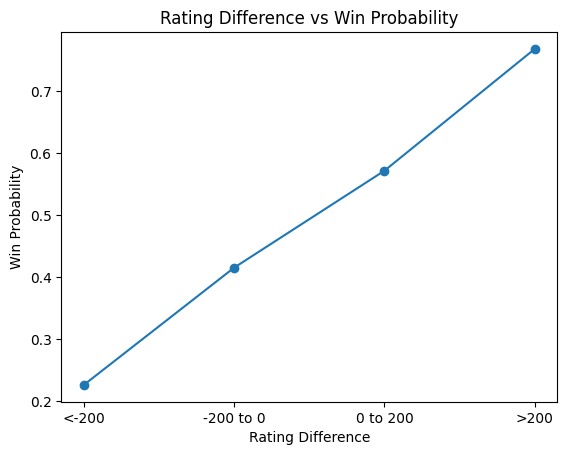

In [9]:
plt.figure()
plt.plot(result['Rating Bin'], result['White Win Probability'], marker='o')

plt.xlabel("Rating Difference")
plt.ylabel("Win Probability")
plt.title("Rating Difference vs Win Probability")

plt.savefig("outputs/figures/RQ1_figure.pdf")
plt.show()

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [11]:
df = pd.read_csv("/kaggle/input/datasets/jordanjesudas/chess-game-dataset/games.csv")
df.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


In [12]:
df['white_win'] = (df['winner'] == 'white').astype(int)

In [13]:
opening_stats = df.groupby('opening_name')['white_win'].mean()

In [14]:
top_openings = opening_stats.sort_values(ascending=False).head(10)
top_openings = top_openings.reset_index()

top_openings.columns = ['Opening', 'White Win Rate']

top_openings

,Opening,White Win Rate
0,Alekhine Defense: Brooklyn Variation,1.0
1,Philidor Defense: Steinitz Variation,1.0
2,Pirc Defense: Austrian Attack | Unzicker Attack,1.0
3,Vienna Game: Omaha Gambit,1.0
4,Benko Gambit Accepted | Fianchetto Variation,1.0
5,Benko Gambit Accepted | Modern Variation,1.0
6,Benko Gambit Accepted | Pawn Return Variation,1.0
7,Benko Gambit Declined | Quiet Line,1.0
8,Alekhine Defense: Mokele Mbembe | Vavra Defense,1.0
9,Alekhine Defense: Scandinavian Variation | Ge...,1.0


In [15]:
import os
os.makedirs("outputs/tables", exist_ok=True)

top_openings.to_csv("outputs/tables/RQ2_openings.csv", index=False)

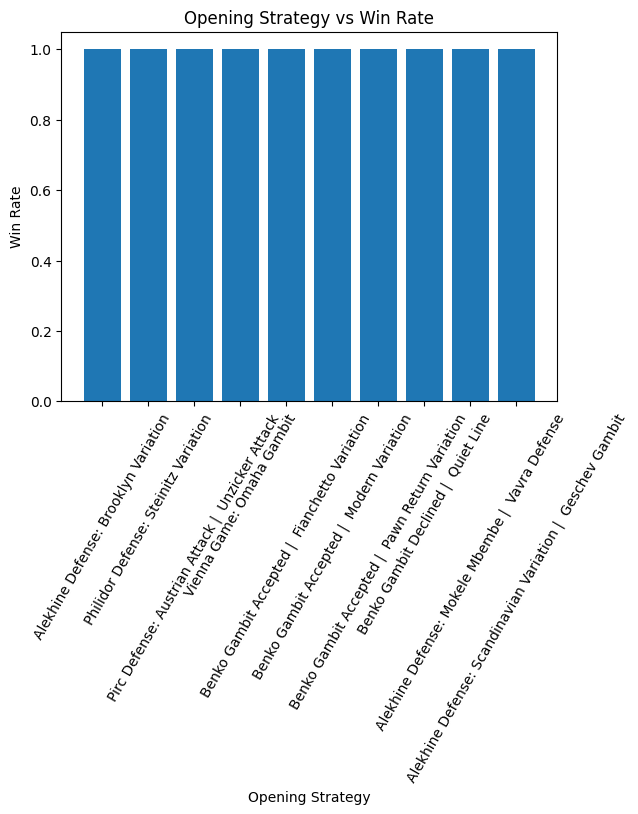

In [16]:
os.makedirs("outputs/figures", exist_ok=True)

plt.figure()
plt.bar(top_openings['Opening'], top_openings['White Win Rate'])

plt.xticks(rotation=60)
plt.xlabel("Opening Strategy")
plt.ylabel("Win Rate")
plt.title("Opening Strategy vs Win Rate")

plt.savefig("outputs/figures/RQ2_figure.pdf")
plt.show()

In [17]:
duration_stats = df.groupby('victory_status')['turns'].mean().reset_index()
duration_stats.columns = ['Victory Type', 'Average Turns']

duration_stats

,Victory Type,Average Turns
0,draw,83.781457
1,mate,65.415020
2,outoftime,72.742857
3,resign,53.912533


In [18]:
import os
os.makedirs("outputs/tables", exist_ok=True)

duration_stats.to_csv("outputs/tables/RQ3_duration.csv", index=False)

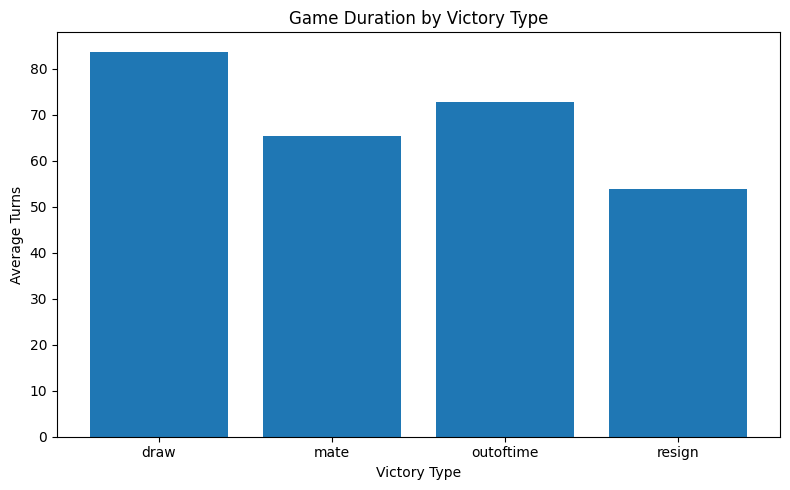

In [19]:
os.makedirs("outputs/figures", exist_ok=True)

plt.figure(figsize=(8,5))

plt.bar(duration_stats['Victory Type'], duration_stats['Average Turns'])

plt.xlabel("Victory Type")
plt.ylabel("Average Turns")
plt.title("Game Duration by Victory Type")

plt.tight_layout()

plt.savefig("outputs/figures/RQ3_figure.pdf")
plt.show()

In [20]:
rated_stats = df.groupby('rated')['turns'].mean().reset_index()
rated_stats.columns = ['Rated', 'Average Turns']

rated_stats

,Rated,Average Turns
0,False,54.271586
1,True,61.962550


In [21]:
import os
os.makedirs("outputs/tables", exist_ok=True)

rated_stats.to_csv("outputs/tables/RQ4_rated.csv", index=False)

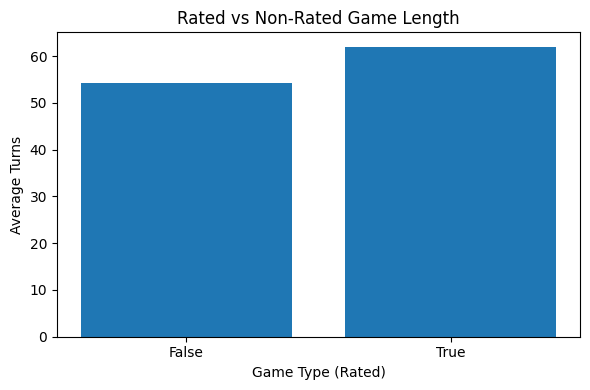

In [22]:
os.makedirs("outputs/figures", exist_ok=True)

plt.figure(figsize=(6,4))

plt.bar(rated_stats['Rated'].astype(str), rated_stats['Average Turns'])

plt.xlabel("Game Type (Rated)")
plt.ylabel("Average Turns")
plt.title("Rated vs Non-Rated Game Length")

plt.tight_layout()

plt.savefig("outputs/figures/RQ4_figure.pdf")
plt.show()

In [23]:
win_dist = df.groupby('rated')['winner'].value_counts(normalize=True).unstack()

win_dist

winner,black,draw,white
rated,,,
False,0.441455,0.059185,0.499359
True,0.457072,0.044506,0.498422


In [24]:
win_dist.to_csv("outputs/tables/RQ4_win_distribution.csv")

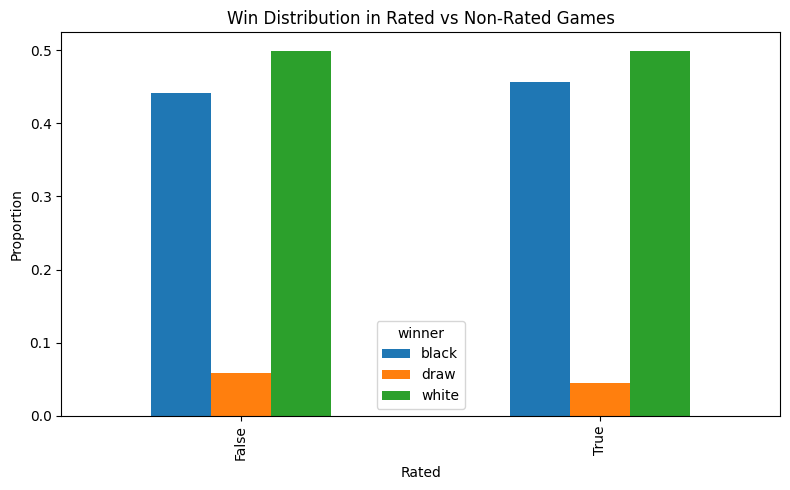

In [25]:
win_dist.plot(kind='bar', figsize=(8,5))

plt.xlabel("Rated")
plt.ylabel("Proportion")
plt.title("Win Distribution in Rated vs Non-Rated Games")

plt.tight_layout()

plt.savefig("outputs/figures/RQ4_win_dist.pdf")
plt.show()

In [26]:
time_stats = df.groupby('increment_code').agg({
    'turns': 'mean',
    'winner': lambda x: (x == 'white').mean()
}).reset_index()

time_stats.columns = ['Time Control', 'Average Turns', 'White Win Rate']

time_stats

,Time Control,Average Turns,White Win Rate
0,0+12,68.000000,0.400000
1,0+13,45.000000,1.000000
2,0+15,60.750000,0.750000
3,0+16,10.400000,0.200000
4,0+180,22.666667,0.444444
...,...,...,...
395,90+0,57.700000,0.600000
396,90+120,125.000000,1.000000
397,90+30,65.230769,0.538462
398,90+5,26.000000,0.000000


In [27]:
top_time = time_stats.sort_values(by='Average Turns', ascending=False).head(10)
top_time

,Time Control,Average Turns,White Win Rate
190,20+11,151.000000,0.000000
129,16+1,137.000000,1.000000
396,90+120,125.000000,1.000000
74,120+5,118.000000,0.000000
99,14+6,112.333333,0.333333
170,19+18,111.000000,1.000000
232,3+30,108.000000,0.000000
209,20+90,108.000000,0.000000
57,12+11,105.000000,1.000000
280,40+15,102.500000,1.000000


In [28]:
import os
os.makedirs("outputs/tables", exist_ok=True)

top_time.to_csv("outputs/tables/RQ5_time_control.csv", index=False)

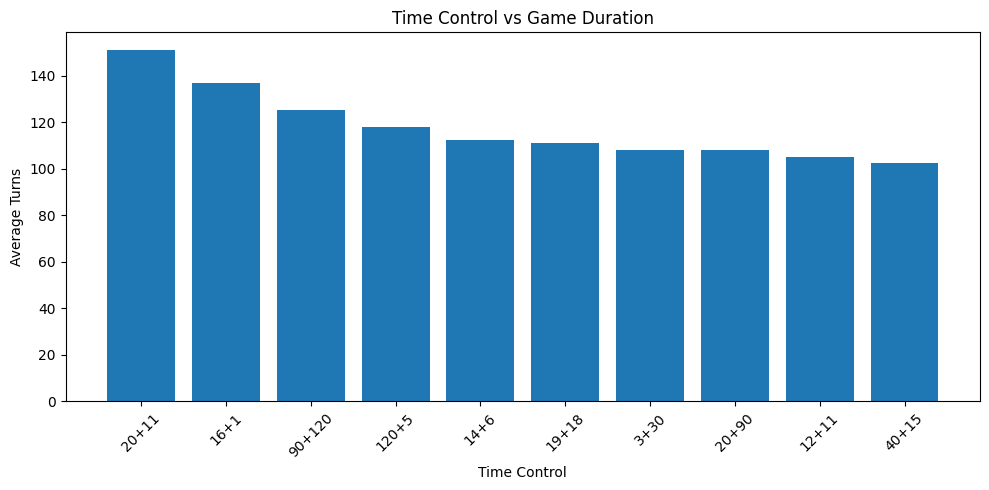

In [29]:
plt.figure(figsize=(10,5))

plt.bar(top_time['Time Control'], top_time['Average Turns'])

plt.xticks(rotation=45)
plt.xlabel("Time Control")
plt.ylabel("Average Turns")
plt.title("Time Control vs Game Duration")

plt.tight_layout()

plt.savefig("outputs/figures/RQ5_duration.pdf")
plt.show()

In [30]:
df['white_win'] = (df['winner'] == 'white').astype(int)

In [31]:
ply_stats = df.groupby('opening_ply')['white_win'].mean().reset_index()
ply_stats.columns = ['Opening Ply', 'White Win Rate']

ply_stats

,Opening Ply,White Win Rate
0,1,0.439380
1,2,0.480409
2,3,0.485100
3,4,0.513603
4,5,0.530037
5,6,0.495545
6,7,0.529762
7,8,0.498208
8,9,0.490539
9,10,0.525463


In [32]:
ply_stats = ply_stats[ply_stats['Opening Ply'] <= 30]

In [33]:
import os
os.makedirs("outputs/tables", exist_ok=True)

ply_stats.to_csv("outputs/tables/RQ6_opening_ply.csv", index=False)

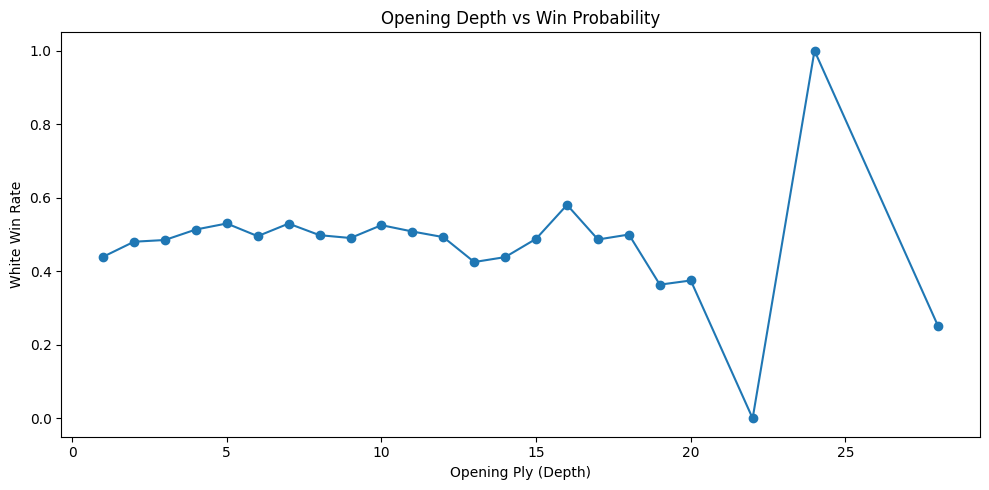

In [34]:
os.makedirs("outputs/figures", exist_ok=True)

plt.figure(figsize=(10,5))

plt.plot(ply_stats['Opening Ply'], ply_stats['White Win Rate'], marker='o')

plt.xlabel("Opening Ply (Depth)")
plt.ylabel("White Win Rate")
plt.title("Opening Depth vs Win Probability")

plt.tight_layout()

plt.savefig("outputs/figures/RQ6_figure.pdf")
plt.show()

In [39]:
X = df[['white_rating', 'black_rating', 'opening_ply']]
y = df['winner']

In [40]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [42]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [43]:
y_pred = model.predict(X_test)

In [44]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

accuracy

0.5989531405782652

In [47]:
from sklearn.linear_model import LogisticRegression

model2 = LogisticRegression(max_iter=1000)
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

from sklearn.metrics import accuracy_score

acc1 = accuracy_score(y_test, y_pred)
acc2 = accuracy_score(y_test, y_pred2)

In [48]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression'],
    'Accuracy': [acc1, acc2]
})

results

,Model,Accuracy
0,Random Forest,0.598953
1,Logistic Regression,0.609422


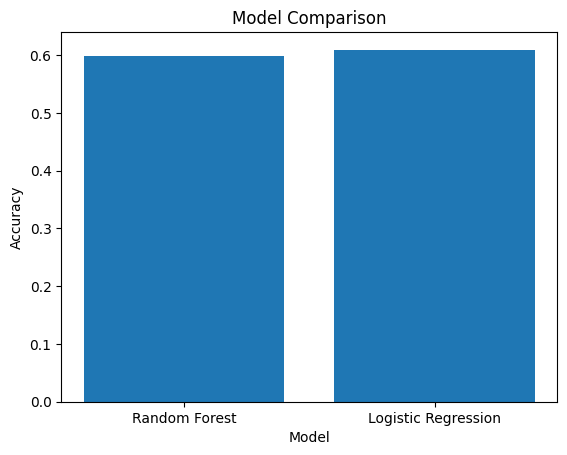

In [49]:
plt.figure()

plt.bar(results['Model'], results['Accuracy'])

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.savefig("outputs/figures/RQ7_figure.pdf")
plt.show()